# Step 6 — Project the 11 ST clusters onto trastuzumab cohorts

Applies the Seurat anchor-based transfer of TCGA's 11 ST-cluster labels onto two
external trastuzumab-treated cohorts:

- **Cedars-Sinai (Ronai_BRCA)** — 30 slides. Params at the top of
  `spatial_clusters/2_Ronai_Seurat_winningc.r`.
- **PBCP — trastuzumab arm** — 18 slides (out of the 37-slide PBCP cohort).
  Params encoded in the column name in `p2s_v2/PBCP/scr/get_aucs.ipynb`.

The two cohorts use **different tuned anchor parameters** — the per-cohort
presets live in `TRANSFER_PRESETS` in
[`../lib/transfer_TCGA_to_external.R`](../lib/transfer_TCGA_to_external.R).

**Inputs (committed under `clustering/data/`)**
- `cedars_sinai_query.qs` — Cedars-Sinai per-domain Seurat object.
- `pbcp_query.qs` — PBCP per-domain Seurat object (full 289 domains; the trastuzumab
  rows are selected by the `treatment == "trastuzumab"` metadata column).

**Outputs (committed under `clustering/data/`)**
- `cedars_sinai_per_domain.csv` / `cedars_sinai_cluster_props.csv` (per-domain predictions, per-patient proportions).
- `pbcp_trastuzumab_per_domain.csv` / `pbcp_trastuzumab_cluster_props.csv` (PBCP trastuzumab subset).

## Setup

In [1]:
import sys, subprocess
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from clustering_helpers import HEATMAP_ROW_ORDER

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

REFERENCE_QS = "/vf/users/Ruppin_ST/scr/new_tras_clusters/tcga_target_seurat_best_genes.qs"

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## What are `target` and `query`?

- **`target` — TCGA reference.** 7,766 SpaGCN domains across 858 TCGA-BRCA slides, with
  the 11 ST cluster labels in `mapped_clusters`. Used identically across notebooks 04–07.
- **`query` — the external cohort.** A Seurat object with one "cell" per SpaGCN domain
  on that cohort's slides. PBCP additionally has `treatment` and `Response` metadata.

The inspector cell below prints summaries of both via R (commented out by default).

In [2]:
def inspect_qs(qs_path, label):
    res = subprocess.run(
        ["bash", "-c",
         f"source /etc/profile.d/modules.sh 2>/dev/null; "
         f"module load R/4.3.2 2>/dev/null; "
         f"Rscript ../lib/inspect_seurat.R {qs_path} '{label}'"],
        capture_output=True, text=True,
    )
    print("\n".join(l for l in res.stdout.splitlines() if "lscratch" not in l))

# inspect_qs(REFERENCE_QS, "TCGA reference (target)")              # uncomment to run
# inspect_qs("../data/cedars_sinai_query.qs", "Cedars-Sinai")
# inspect_qs("../data/pbcp_query.qs", "PBCP")

## Stage 1 — Project labels

Each cohort uses its own preset. The helper script accepts the preset name as the
4th CLI argument. Calls are commented out by default; the outputs are shipped
pre-computed under `data/`.

In [3]:
# Uncomment to re-run (needs R + Seurat + access to the upstream TCGA .qs):
# subprocess.run(["bash", "-c",
#     f"source /etc/profile.d/modules.sh; module load R/4.3.2; "
#     f"Rscript ../lib/transfer_TCGA_to_external.R "
#     f"{REFERENCE_QS} ../data/cedars_sinai_query.qs ../data/cedars_sinai_cluster_props.csv Cedars_Sinai"],
#     check=True)
#
# subprocess.run(["bash", "-c",
#     f"source /etc/profile.d/modules.sh; module load R/4.3.2; "
#     f"Rscript ../lib/transfer_TCGA_to_external.R "
#     f"{REFERENCE_QS} ../data/pbcp_query.qs ../data/pbcp_trastuzumab_cluster_props.csv PBCP_Trastuzumab"],
#     check=True)
# Note: the PBCP_Trastuzumab preset is applied to the FULL PBCP Seurat object
# (289 domains, both treatments). The trastuzumab subset is selected downstream
# by `treatment == "trastuzumab"`. The committed CSV has that subset only.

cs_props  = pd.read_csv("../data/cedars_sinai_cluster_props.csv",       index_col=0)
pbcp_props = pd.read_csv("../data/pbcp_trastuzumab_cluster_props.csv",  index_col=0)
print("Cedars-Sinai:        ", cs_props.shape,  "patients")
print("PBCP trastuzumab:    ", pbcp_props.shape, "patients")

Cedars-Sinai:         (30, 11) patients
PBCP trastuzumab:     (18, 11) patients


## Stage 2 — Heatmap of cluster proportions per cohort (z-score)

Row-wise z-score (per cluster across patients). Rows in the paper-frozen order;
patients ordered by Ward dendrogram within each cohort. Same colour scale as
notebooks 03 and 04.

In [4]:
def _zscore_rows(M):
    mu = M.mean(axis=1, keepdims=True); s = M.std(axis=1, keepdims=True)
    s[s == 0] = 1
    return (M - mu) / s

def draw_cohort_heatmap(props_csv, title, max_cols=None):
    df = pd.read_csv(props_csv, index_col=0)
    df = df.rename(columns={f"Cluster_{i}": f"Cluster {i}" for i in range(1, 12)})
    # Order patients by Ward dendrogram across all 11 clusters
    from scipy.cluster.hierarchy import linkage, leaves_list
    sub_mat = df[HEATMAP_ROW_ORDER].values
    if len(df) > 1:
        order = leaves_list(linkage(sub_mat, method="ward"))
    else:
        order = np.arange(len(df))
    raw = df.iloc[order][HEATMAP_ROW_ORDER].T.values
    heat = _zscore_rows(raw)

    from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
    v_lo, v_mid, v_hi = float(heat.min()), 2.85, float(heat.max())
    cmap = LinearSegmentedColormap.from_list(
        "viridis3", plt.get_cmap("viridis")(np.linspace(0, 1, 3)), N=256
    )
    norm = TwoSlopeNorm(vmin=v_lo, vcenter=min(v_mid, v_hi - 1e-6), vmax=v_hi)

    fig = plt.figure(figsize=(max(4.2, 0.18 * heat.shape[1] + 2), 3.0))
    gs  = gridspec.GridSpec(1, 2, figure=fig,
                             width_ratios=[60, 1], hspace=0.05, wspace=0.02)
    ax_h = fig.add_subplot(gs[0, 0])
    im = ax_h.imshow(heat, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
    ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
    ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
    ax_h.set_xticks([]); ax_h.tick_params(left=False)
    ax_h.set_title(title, fontsize=8)
    ax_cb = fig.add_subplot(gs[0, 1])
    plt.colorbar(im, cax=ax_cb).set_label("Z-score", fontsize=7)
    ax_cb.tick_params(labelsize=6)
    plt.show()

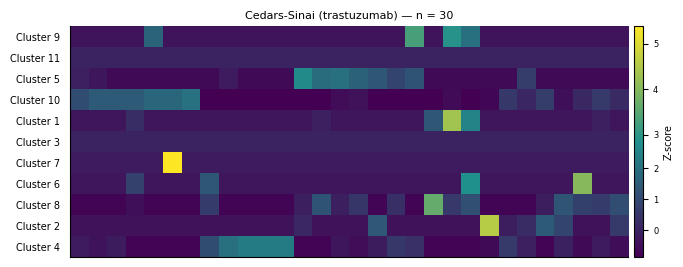

In [5]:
draw_cohort_heatmap("../data/cedars_sinai_cluster_props.csv",
                    "Cedars-Sinai (trastuzumab) — n = " + str(len(cs_props)))

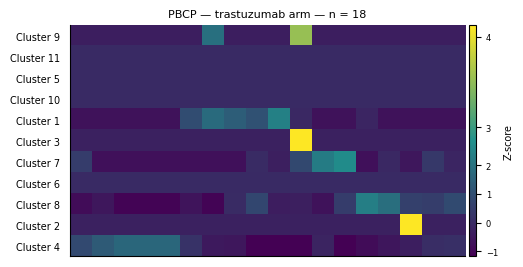

In [6]:
draw_cohort_heatmap("../data/pbcp_trastuzumab_cluster_props.csv",
                    "PBCP — trastuzumab arm — n = " + str(len(pbcp_props)))